### Import required packages

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from PIL import Image

### Check hardware

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'Using GPU: {torch.cuda.get_device_name(0)}')
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print(f'Using MPS: {torch.mps.is_available()}')

else:
    device = torch.device('cpu')
    print('Using CPU')

Using GPU: NVIDIA GeForce GTX 1660 SUPER
Memory: 6.44 GB


### Load IAM dataset

In [3]:
from pathlib import Path
from torch.utils.data import random_split

iam_path = "data/raw/"

required_files = [
    "ascii/lines.txt",
    "lines/"
]


for file in required_files:
    file_path = Path(iam_path) / file
    if not file_path.exists():
        raise FileNotFoundError(f"Не найден обязательный путь: {file_path}")
    if file_path.is_dir():
        files_count = sum(1 for p in file_path.rglob("*") if p.is_file())
        if files_count == 0:
            raise FileNotFoundError(f"Папка пуста: {file_path}")
        print(f"OK: {file_path} (папка, файлов: {files_count})")
    else:
        file_size = file_path.stat().st_size
        if file_size == 0:
            raise ValueError(f"Файл пустой: {file_path}")
        print(f"OK: {file_path} (файл, {file_size} байт)")

OK: data\raw\ascii\lines.txt (файл, 1110091 байт)
OK: data\raw\lines (папка, файлов: 13353)


### Parse dataset

In [45]:
data_samples = []
missing_images = 0

lines_file = Path(iam_path) / "ascii/lines.txt"

data_root = Path(iam_path).resolve()

with open(lines_file, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line == "" or line.startswith("#"):
            continue

        parts = line.split()
        # print(f"Line parts: {parts}")
        line_id = parts[0]
        status = parts[1]
        box_x, box_y, box_w, box_h = map(int, parts[4:8])
        transcription = " ".join(parts[8:][0].split("|"))
        # print(f"Processing line: {line_id}, status: {status}, box: ({box_x}, {box_y}, {box_w}, {box_h}), transcription: {transcription}")

        prefix = line_id.split("-")[0]
        form_page = "-".join(line_id.split("-")[:2])
        image_path = data_root / "lines" / prefix / form_page / f"{line_id}.png"
        # print(f"Prefix: {prefix}, Form page: {form_page}, Image path: {image_path}")

        if not image_path.exists():
            missing_images += 1
            continue

        data_samples.append(
            {
            "line_id": line_id,
            "transcription": transcription,
            "image_path": image_path,
            "bbox": (box_x, box_y, box_w, box_h),
            }
        )

print(f"Всего образцов: {len(data_samples)}, пропущено из-за отсутствия изображений: {missing_images}")

if len(data_samples) != 0:
    print(f"Пример образца: {data_samples[0]}")
else:
    print("Нет доступных образцов для обработки.")

Всего образцов: 13353, пропущено из-за отсутствия изображений: 0
Пример образца: {'line_id': 'a01-000u-00', 'transcription': 'A MOVE to stop Mr. Gaitskell from', 'image_path': WindowsPath('C:/prog/gitrepos/Handwriting_OCR-spbu/data/raw/lines/a01/a01-000u/a01-000u-00.png'), 'bbox': (408, 746, 1661, 89)}


### Inspect dataset

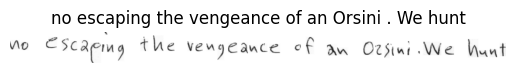

In [53]:
from PIL import Image
import matplotlib.pyplot as plt

def visualize_sample(sample):
    img_path = sample["image_path"]
    bbox = sample["bbox"]
    transcription = sample["transcription"]

    try:
        img = Image.open(img_path).convert("RGB")
        plt.imshow(img)
        plt.title(transcription)
        plt.gca().add_patch(plt.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], edgecolor='red', facecolor='none', linewidth=2))
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Ошибка при загрузке изображения: {e}")


visualize_sample(data_samples[10000])